# Python for Petroleum Engineers

        Welcome to a practical course built around petroleum-engineering decisions and
        calculations. Every dataset is synthetic, every notebook is executable, and units are
        written directly into names and labels. Start here, then follow the numbered modules.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

wells = pd.read_csv(ROOT / "data" / "synthetic_wells.csv")
ift = pd.read_csv(ROOT / "data" / "synthetic_ift.csv")
production = pd.read_csv(ROOT / "data" / "synthetic_production.csv")
wells.head()


,well_id,field,x_m,y_m,net_pay_m,porosity_fraction,water_saturation_fraction,permeability_md,pressure_mpa,temperature_k,oil_rate_bpd
0,W-01,North,4246.2,5106.8,13.49,0.1862,0.4439,82.25,21.41,352.37,335.1
1,W-02,North,4848.1,260.9,22.66,0.2528,0.3116,42.40,22.91,354.51,214.5
2,W-03,South,6941.9,1089.0,19.92,0.2046,0.3657,72.48,20.15,346.58,309.4
3,W-04,South,4824.9,1420.5,17.22,0.1950,0.3800,20.75,25.78,352.32,66.2
4,W-05,Central,3300.6,1496.3,17.80,0.1977,0.3922,38.68,23.38,365.40,184.1


## A first engineering view

        Good analysis begins with data provenance, dimensions, units, and plausible ranges—not
        with a complicated model.

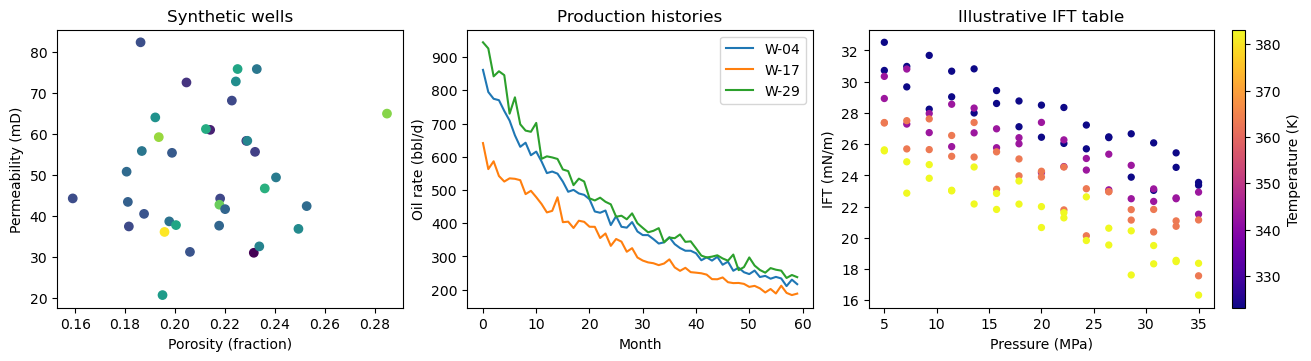

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
axes[0].scatter(wells["porosity_fraction"], wells["permeability_md"], c=wells["pressure_mpa"], cmap="viridis")
axes[0].set(xlabel="Porosity (fraction)", ylabel="Permeability (mD)", title="Synthetic wells")
for well, group in production.groupby("well_id"):
    axes[1].plot(group["month"], group["oil_rate_bpd"], label=well)
axes[1].set(xlabel="Month", ylabel="Oil rate (bbl/d)", title="Production histories")
axes[1].legend()
scatter = axes[2].scatter(ift["pressure_mpa"], ift["ift_mn_m"], c=ift["temperature_k"], cmap="plasma", s=18)
axes[2].set(xlabel="Pressure (MPa)", ylabel="IFT (mN/m)", title="Illustrative IFT table")
fig.colorbar(scatter, ax=axes[2], label="Temperature (K)")
plt.show()


## Reproducibility contract

        Use a fixed seed for random work, do not overwrite raw input, validate physical ranges,
        keep units explicit, and state limitations beside results. The examples are educational,
        not field-development tools.